# CODE

In [1]:
# ===================================================================
# 1. IMPOR PUSTAKA
# ===================================================================
import pandas as pd
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE

# ===================================================================
# 2. PEMUATAN DAN INTEGRASI DATA
# ===================================================================
# Definisi nama file dataset
file_utama = "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"
file_tambahan = "Monday-WorkingHours.pcap_ISCX.csv"

# Memuat file dataset
print("Memulai proses pemuatan data...")
df_utama = pd.read_csv(file_utama)
df_tambahan = pd.read_csv(file_tambahan)

print("Menggabungkan dataset utama dan tambahan...")
# Bersihkan nama kolom dari spasi
df_utama.columns = df_utama.columns.str.strip()
df_tambahan.columns = df_tambahan.columns.str.strip()

# Pisahkan data BENIGN dari dataset tambahan
data_tambahan_benign = df_tambahan[df_tambahan['Label'] == 'BENIGN'].copy()

# Gabungkan dataset utama dengan data BENIGN tambahan
df_combined = pd.concat([df_utama, data_tambahan_benign], ignore_index=True)

print("\nRingkasan integrasi data:")
print(f"Jumlah baris dataset utama: {len(df_utama)}")
print(f"Jumlah baris BENIGN ditambahkan: {len(data_tambahan_benign)}")
print(f"Total baris data gabungan: {len(df_combined)}")

print("\nDistribusi kelas pada dataset gabungan:")
print(df_combined['Label'].value_counts())

# ===================================================================
# 3. PRA-PEMROSESAN DATA
# ===================================================================
print("\nMemulai pra-pemrosesan data...")
df_processed = df_combined.copy()

# Tangani nilai infiniti dan hapus baris dengan nilai yang hilang
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)
df_processed.dropna(inplace=True)

# Encoding pada label target: BENIGN -> 0, PortScan -> 1
df_processed['Label'] = df_processed['Label'].map({'BENIGN': 0, 'PortScan': 1})
df_processed = df_processed[df_processed['Label'].isin([0, 1])]

# Pisahkan fitur (X) dan target (y)
y = df_processed['Label'].astype(int)
X = df_processed.drop('Label', axis=1)

# Encoding pada fitur kategoris
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])
print("Pra-pemrosesan selesai.")

# ===================================================================
# 4. PEMBAGIAN DATA (RASIO 80:20)
# ===================================================================
print("\nMembagi data menjadi 80% latih dan 20% uji...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Ukuran data latih: {X_train.shape[0]} sampel")
print(f"Ukuran data uji: {X_test.shape[0]} sampel")

# ===================================================================
# 5. PENSKALAAN DAN PENGGUNAAN SELURUH FITUR
# ===================================================================
print("\nMenerapkan penskalaan pada seluruh fitur...")
# Penskalaan Fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hapus fitur dengan varians nol (fitur yang nilainya konstan)
var_thresh = VarianceThreshold()
X_train_final = var_thresh.fit_transform(X_train_scaled)
X_test_final = var_thresh.transform(X_test_scaled)

print(f"\nJumlah fitur yang digunakan setelah menghapus fitur varians nol: {X_train_final.shape[1]}")
print(f"Dimensi set latih: {X_train_final.shape}")
print(f"Dimensi set uji: {X_test_final.shape}")

# ===================================================================
# 6. DEFINISI MODEL
# ===================================================================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=2, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(n_estimators=50, max_depth=2, learning_rate=0.2, reg_alpha=0.5, reg_lambda=1, eval_metric='logloss', random_state=42),
    "SVM": SVC(kernel='linear', C=0.1, class_weight='balanced', probability=True)
}

# ===================================================================
# 7. PROSES PELATIHAN DAN EVALUASI
# ===================================================================
print("\n" + "="*50)
print("Memulai Proses Pelatihan dan Evaluasi")
print("="*50)

print("\nMenerapkan SMOTE pada data latih...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)
print("Distribusi kelas data latih setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# Dictionary untuk menyimpan hasil prediksi dari setiap model
predictions_no_smote = {}
predictions_with_smote = {}
evaluation_results = []

for name, model_template in models.items():
    # --- Skenario 1: Tanpa SMOTE ---
    print(f"\n--- Melatih dan Mengevaluasi {name} (Tanpa SMOTE) ---")
    model_no_smote = copy.deepcopy(model_template)
    model_no_smote.fit(X_train_final, y_train)
    y_pred = model_no_smote.predict(X_test_final)
    
    # Simpan hasil prediksi untuk confusion matrix
    predictions_no_smote[name] = y_pred
    
    print(f"Laporan Performa pada Data Uji (20%):")
    print(classification_report(y_test, y_pred, zero_division=0, digits=4))
    
    evaluation_results.append({
        'Model': name,
        'Skenario': 'Tanpa SMOTE',
        'Akurasi': accuracy_score(y_test, y_pred),
        'Presisi': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

    # --- Skenario 2: Dengan SMOTE ---
    print(f"\n--- Melatih dan Mengevaluasi {name} (Dengan SMOTE) ---")
    model_with_smote = copy.deepcopy(model_template)
    model_with_smote.fit(X_train_smote, y_train_smote)
    y_pred_smote = model_with_smote.predict(X_test_final)
    
    # Simpan hasil prediksi untuk confusion matrix
    predictions_with_smote[name] = y_pred_smote
    
    print(f"Laporan Performa pada Data Uji (20%):")
    print(classification_report(y_test, y_pred_smote, zero_division=0, digits=4))

    evaluation_results.append({
        'Model': name,
        'Skenario': 'Dengan SMOTE',
        'Akurasi': accuracy_score(y_test, y_pred_smote),
        'Presisi': precision_score(y_test, y_pred_smote, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred_smote, average='weighted', zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_smote, average='weighted', zero_division=0)
    })

# ===================================================================
# 8. HASIL AKHIR DAN PERBANDINGAN
# ===================================================================
results_df = pd.DataFrame(evaluation_results)

print("\n\n" + "="*60)
print(" Ringkasan Akhir: Perbandingan Performa Model pada Data Uji ")
print("="*60)
# Mengurutkan hasil berdasarkan F1-Score
print(results_df.round(4).sort_values(by='F1-Score', ascending=False))

Memulai proses pemuatan data...
Menggabungkan dataset utama dan tambahan...

Ringkasan integrasi data:
Jumlah baris dataset utama: 286467
Jumlah baris BENIGN ditambahkan: 529918
Total baris data gabungan: 816385

Distribusi kelas pada dataset gabungan:
Label
BENIGN      657455
PortScan    158930
Name: count, dtype: int64

Memulai pra-pemrosesan data...
Pra-pemrosesan selesai.

Membagi data menjadi 80% latih dan 20% uji...
Ukuran data latih: 652461 sampel
Ukuran data uji: 163116 sampel

Menerapkan penskalaan pada seluruh fitur...

Jumlah fitur yang digunakan setelah menghapus fitur varians nol: 68
Dimensi set latih: (652461, 68)
Dimensi set uji: (163116, 68)

Memulai Proses Pelatihan dan Evaluasi

Menerapkan SMOTE pada data latih...


C:\Users\aanha\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\aanha\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Distribusi kelas data latih setelah SMOTE:
Label
0    525418
1    525418
Name: count, dtype: int64

--- Melatih dan Mengevaluasi Random Forest (Tanpa SMOTE) ---
Laporan Performa pada Data Uji (20%):
              precision    recall  f1-score   support

           0     0.9981    0.9956    0.9968    131355
           1     0.9820    0.9920    0.9870     31761

    accuracy                         0.9949    163116
   macro avg     0.9900    0.9938    0.9919    163116
weighted avg     0.9949    0.9949    0.9949    163116


--- Melatih dan Mengevaluasi Random Forest (Dengan SMOTE) ---
Laporan Performa pada Data Uji (20%):
              precision    recall  f1-score   support

           0     0.9981    0.9956    0.9968    131355
           1     0.9818    0.9920    0.9869     31761

    accuracy                         0.9949    163116
   macro avg     0.9899    0.9938    0.9918    163116
weighted avg     0.9949    0.9949    0.9949    163116


--- Melatih dan Mengevaluasi XGBoost (Tanpa S

In [2]:
# ===================================================================
# KODE TAMBAHAN: Identifikasi Fitur yang Digunakan dan Dihapus
# ===================================================================

print("\n" + "="*60)
print("Analisis Hasil Seleksi Fitur VarianceThreshold")
print("="*60)

# 1. Dapatkan daftar nama semua fitur asli (sebelum seleksi)
original_features = X.columns.tolist()

# 2. Dapatkan daftar nama fitur yang lolos seleksi (yang digunakan)
#    var_thresh.get_support() menghasilkan array boolean [True, False, True, ...]
#    yang kita gunakan untuk memfilter nama kolom asli.
final_feature_names = X.columns[var_thresh.get_support()].tolist()

# 3. Hitung fitur yang dihapus dengan mencari perbedaan antara kedua daftar
removed_features = list(set(original_features) - set(final_feature_names))

# 4. Tampilkan hasilnya
print(f"Total fitur asli: {len(original_features)}")
print(f"Total fitur yang digunakan: {len(final_feature_names)}")
print(f"Total fitur yang dihapus: {len(removed_features)}")

print("\n--- Fitur yang Dieliminasi (Varians Nol) ---")
# Urutkan agar lebih mudah dibaca
removed_features.sort()
print(removed_features)

print("\n--- Fitur yang Digunakan ---")
print(final_feature_names)
print("="*60)



Analisis Hasil Seleksi Fitur VarianceThreshold
Total fitur asli: 78
Total fitur yang digunakan: 68
Total fitur yang dihapus: 10

--- Fitur yang Dieliminasi (Varians Nol) ---
['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd URG Flags']

--- Fitur yang Digunakan ---
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'B

In [3]:
kolom_varian_nol = [
    'Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 
    'Bwd PSH Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bulk Rate', 
    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd URG Flags'
]

df_cek = df_processed[kolom_varian_nol]

print(df_cek.describe())

apakah_semua_nol = (df_processed[kolom_varian_nol] == 0).all().all()

print(f"\nApakah semua nilai di kolom tersebut nol? -> {apakah_semua_nol}")

       Bwd Avg Bulk Rate  Bwd Avg Bytes/Bulk  Bwd Avg Packets/Bulk  \
count           815577.0            815577.0              815577.0   
mean                 0.0                 0.0                   0.0   
std                  0.0                 0.0                   0.0   
min                  0.0                 0.0                   0.0   
25%                  0.0                 0.0                   0.0   
50%                  0.0                 0.0                   0.0   
75%                  0.0                 0.0                   0.0   
max                  0.0                 0.0                   0.0   

       Bwd PSH Flags  Bwd URG Flags  CWE Flag Count  Fwd Avg Bulk Rate  \
count       815577.0       815577.0        815577.0           815577.0   
mean             0.0            0.0             0.0                0.0   
std              0.0            0.0             0.0                0.0   
min              0.0            0.0             0.0                0.0   


Membuat visualisasi heatmap korelasi untuk fitur yang digunakan...

Visualisasi heatmap telah disimpan sebagai 'heatmap_korelasi.png'


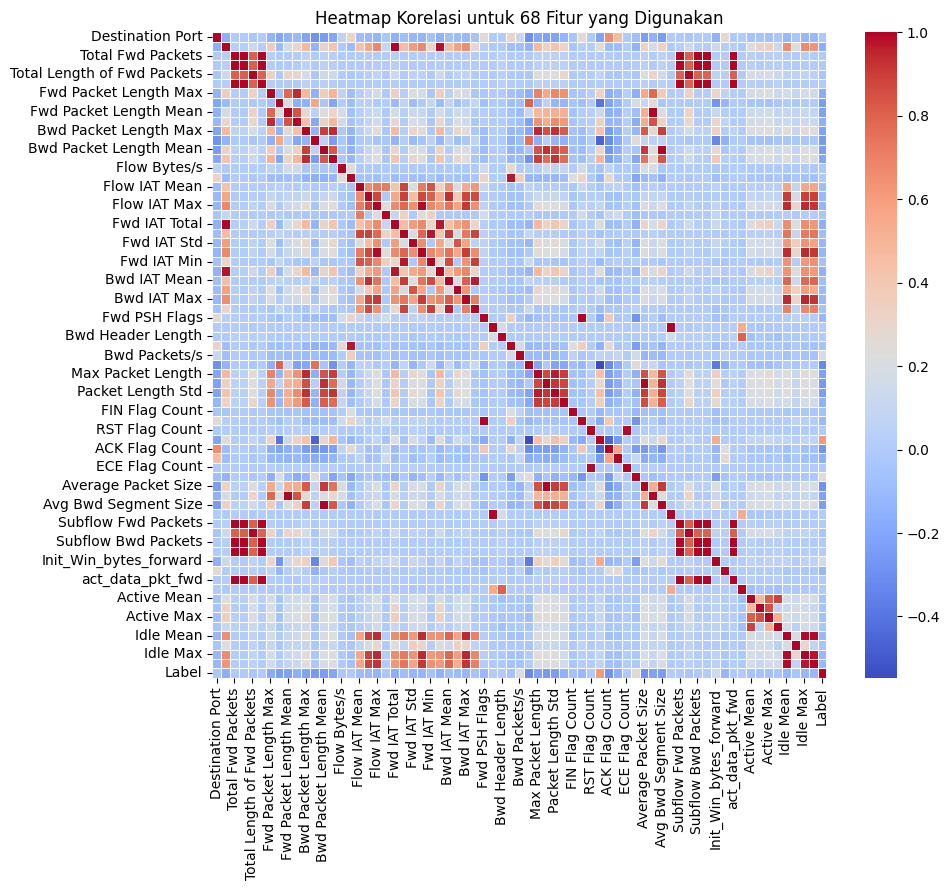

In [4]:
# ===================================================================
# 9. VISUALISASI FITUR YANG DIGUNAKAN
# ===================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("\nMembuat visualisasi heatmap korelasi untuk fitur yang digunakan...")

# Mengambil nama kolom asli sebelum diubah menjadi array numpy
# Menerapkan filter dari VarianceThreshold untuk mendapatkan nama fitur final
final_feature_names = X.columns[var_thresh.get_support()]

# Membuat DataFrame sementara dari data latih yang sudah diproses
# Ini diperlukan untuk menghitung korelasi antar fitur
temp_df_train = pd.DataFrame(X_train_final, columns=final_feature_names)
temp_df_train['Label'] = y_train.values

# Menghitung matriks korelasi
correlation_matrix = temp_df_train.corr()

# Mengatur ukuran plot agar lebih besar dan mudah dibaca
plt.figure(figsize=(10, 9))

# Membuat heatmap dengan seaborn
# Anotasi (angka) dimatikan (annot=False) karena jumlah fitur yang banyak akan
# membuat angka tumpang tindih dan tidak terbaca. Pola warna lebih penting di sini.
sns.heatmap(
    correlation_matrix, 
    annot=False, 
    cmap='coolwarm', # Skema warna: biru (negatif), merah (positif)
    linewidths=.5
)

plt.title(f'Heatmap Korelasi untuk {len(final_feature_names)} Fitur yang Digunakan', fontsize=12)
plt.xticks(rotation=90) # Memutar label sumbu X agar tidak tumpang tindih
plt.yticks(rotation=0)
plt.tight_layout() # Menyesuaikan layout agar tidak terpotong

plt.savefig('heatmap_korelasi.png', dpi=300, bbox_inches='tight')
print("\nVisualisasi heatmap telah disimpan sebagai 'heatmap_korelasi.png'")

plt.show()




################
CONFUSION MATRIX
################

Hasil Analisis untuk: Random Forest (Tanpa SMOTE)


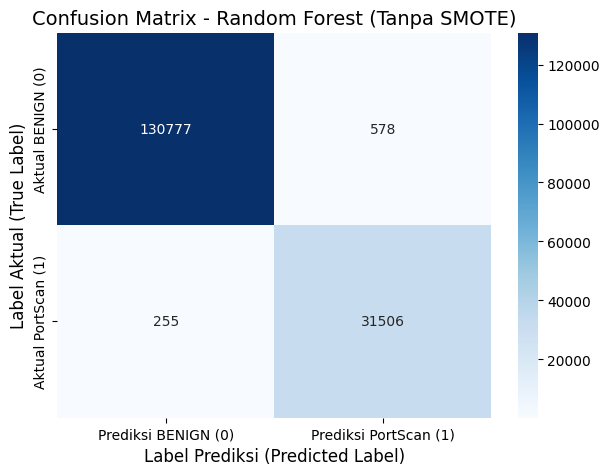


Detail Komponen Confusion Matrix:
-> True Positives  (TP): 31506 (PortScan diprediksi benar sebagai PortScan)
-> True Negatives  (TN): 130777 (BENIGN diprediksi benar sebagai BENIGN)
-> False Positives (FP):   578 (BENIGN salah diprediksi sebagai PortScan) - Type I Error
-> False Negatives (FN):   255 (PortScan salah diprediksi sebagai BENIGN) - Type II Error

Hasil Analisis untuk: XGBoost (Tanpa SMOTE)


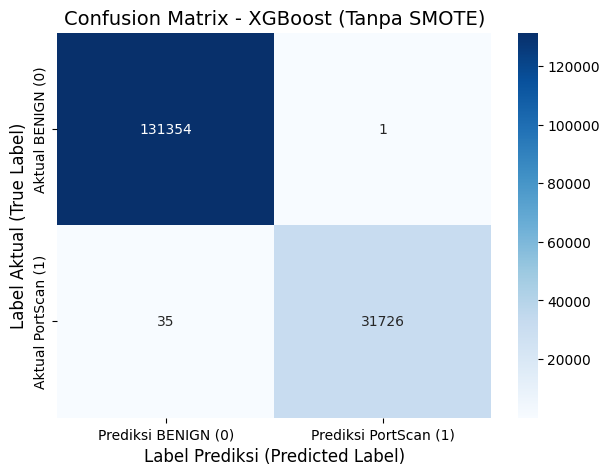


Detail Komponen Confusion Matrix:
-> True Positives  (TP): 31726 (PortScan diprediksi benar sebagai PortScan)
-> True Negatives  (TN): 131354 (BENIGN diprediksi benar sebagai BENIGN)
-> False Positives (FP):     1 (BENIGN salah diprediksi sebagai PortScan) - Type I Error
-> False Negatives (FN):    35 (PortScan salah diprediksi sebagai BENIGN) - Type II Error

Hasil Analisis untuk: SVM (Tanpa SMOTE)


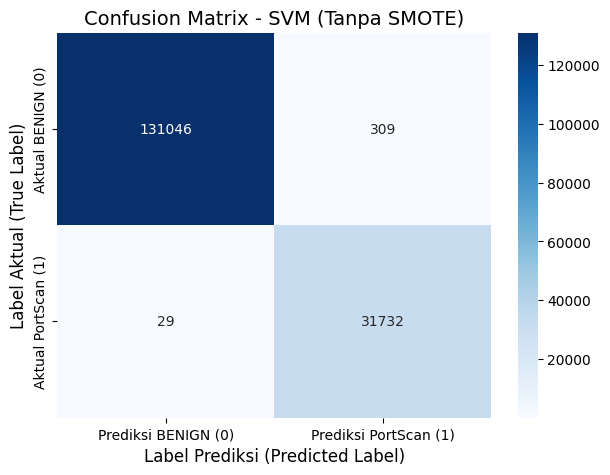


Detail Komponen Confusion Matrix:
-> True Positives  (TP): 31732 (PortScan diprediksi benar sebagai PortScan)
-> True Negatives  (TN): 131046 (BENIGN diprediksi benar sebagai BENIGN)
-> False Positives (FP):   309 (BENIGN salah diprediksi sebagai PortScan) - Type I Error
-> False Negatives (FN):    29 (PortScan salah diprediksi sebagai BENIGN) - Type II Error

Hasil Analisis untuk: Random Forest (Dengan SMOTE)


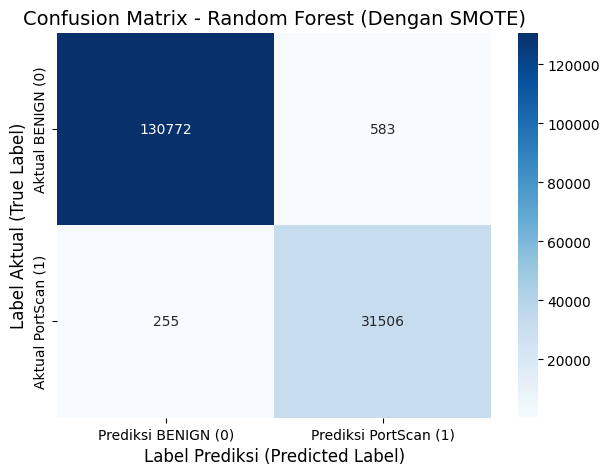


Detail Komponen Confusion Matrix:
-> True Positives  (TP): 31506 (PortScan diprediksi benar sebagai PortScan)
-> True Negatives  (TN): 130772 (BENIGN diprediksi benar sebagai BENIGN)
-> False Positives (FP):   583 (BENIGN salah diprediksi sebagai PortScan) - Type I Error
-> False Negatives (FN):   255 (PortScan salah diprediksi sebagai BENIGN) - Type II Error

Hasil Analisis untuk: XGBoost (Dengan SMOTE)


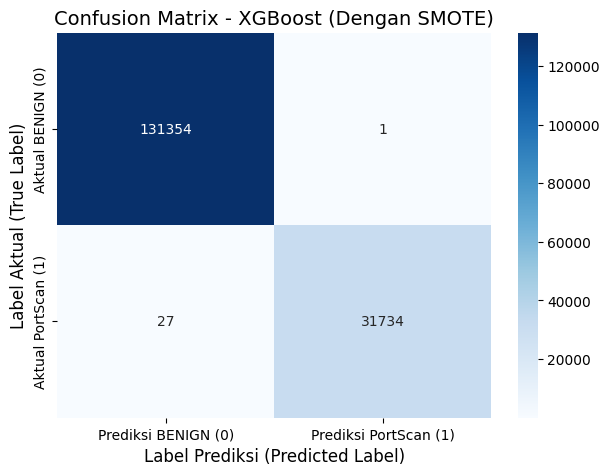


Detail Komponen Confusion Matrix:
-> True Positives  (TP): 31734 (PortScan diprediksi benar sebagai PortScan)
-> True Negatives  (TN): 131354 (BENIGN diprediksi benar sebagai BENIGN)
-> False Positives (FP):     1 (BENIGN salah diprediksi sebagai PortScan) - Type I Error
-> False Negatives (FN):    27 (PortScan salah diprediksi sebagai BENIGN) - Type II Error

Hasil Analisis untuk: SVM (Dengan SMOTE)


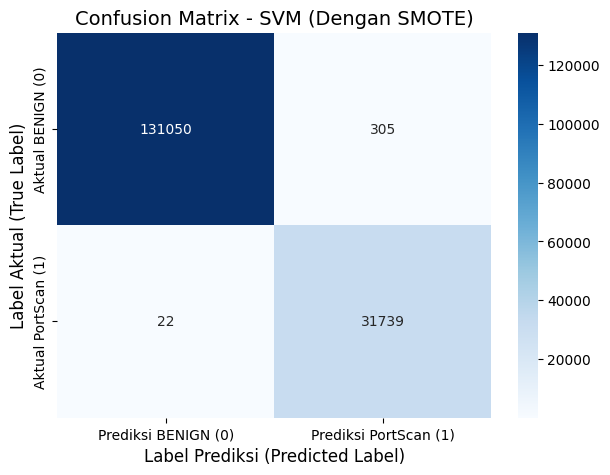


Detail Komponen Confusion Matrix:
-> True Positives  (TP): 31739 (PortScan diprediksi benar sebagai PortScan)
-> True Negatives  (TN): 131050 (BENIGN diprediksi benar sebagai BENIGN)
-> False Positives (FP):   305 (BENIGN salah diprediksi sebagai PortScan) - Type I Error
-> False Negatives (FN):    22 (PortScan salah diprediksi sebagai BENIGN) - Type II Error


 TABEL PERBANDINGAN METRIK DETAIL - Skenario Tanpa SMOTE
           Model  Akurasi  Presisi (BENIGN)  Recall (BENIGN)  \
0  Random Forest   0.9949            0.9981           0.9956   
1        XGBoost   0.9998            0.9997           1.0000   
2            SVM   0.9979            0.9998           0.9976   

   F1-Score (BENIGN)  Presisi (PortScan)  Recall (PortScan)  \
0             0.9968              0.9820             0.9920   
1             0.9999              1.0000             0.9989   
2             0.9987              0.9904             0.9991   

   F1-Score (PortScan)  
0               0.9870  
1               0.

In [5]:
# ===================================================================
# 1. IMPOR PUSTAKA UNTUK VISUALISASI DAN ANALISIS
# ===================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Pastikan variabel `y_test`, `predictions_no_smote`, dan `predictions_with_smote`
# sudah ada dari eksekusi CODE UTAMA sebelumnya.

# ===================================================================
# 2. FUNGSI UNTUK VISUALISASI CONFUSION MATRIX
# ===================================================================
def plot_confusion_matrix_and_metrics(y_true, y_pred, title):
    """
    Fungsi untuk menghitung, mem-plot confusion matrix, dan menampilkan
    nilai TP, FN, FP, TN.
    """
    # Hitung confusion matrix
    # Label 0 = BENIGN (Negatif)
    # Label 1 = PortScan (Positif)
    cm = confusion_matrix(y_true, y_pred)
    
    # Ekstrak nilai TP, TN, FP, FN dari matrix
    # Format: tn, fp, fn, tp
    tn, fp, fn, tp = cm.ravel()

    print("\n" + "="*55)
    print(f"Hasil Analisis untuk: {title}")
    print("="*55)
    
    # Tampilkan confusion matrix menggunakan heatmap
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Prediksi BENIGN (0)', 'Prediksi PortScan (1)'],
                yticklabels=['Aktual BENIGN (0)', 'Aktual PortScan (1)'])
    plt.title(f'Confusion Matrix - {title}', fontsize=14)
    plt.ylabel('Label Aktual (True Label)', fontsize=12)
    plt.xlabel('Label Prediksi (Predicted Label)', fontsize=12)
    plt.show()

    # Tampilkan perhitungan manual
    print("\nDetail Komponen Confusion Matrix:")
    print(f"-> True Positives  (TP): {tp:>5} (PortScan diprediksi benar sebagai PortScan)")
    print(f"-> True Negatives  (TN): {tn:>5} (BENIGN diprediksi benar sebagai BENIGN)")
    print(f"-> False Positives (FP): {fp:>5} (BENIGN salah diprediksi sebagai PortScan) - Type I Error")
    print(f"-> False Negatives (FN): {fn:>5} (PortScan salah diprediksi sebagai BENIGN) - Type II Error")
    print("="*55)


# ===================================================================
# 3. GENERATE VISUALISASI UNTUK SETIAP MODEL PADA DATA UJI
# ===================================================================
print("\n\n" + "#"*16)
print("CONFUSION MATRIX")
print("#"*16)

# --- Skenario 1: Model yang Dilatih Tanpa SMOTE ---
for name, y_pred_data in predictions_no_smote.items():
    plot_confusion_matrix_and_metrics(y_test, y_pred_data, f"{name} (Tanpa SMOTE)")

# --- Skenario 2: Model yang Dilatih Dengan SMOTE ---
for name, y_pred_data in predictions_with_smote.items():
    plot_confusion_matrix_and_metrics(y_test, y_pred_data, f"{name} (Dengan SMOTE)")

# ===================================================================
# 4. FUNGSI UNTUK MEMBUAT TABEL PERBANDINGAN METRIK
# ===================================================================
def create_comparison_table(y_true, predictions_dict, scenario_name):
    """
    Fungsi untuk membuat dan menampilkan tabel perbandingan metrik yang detail
    untuk setiap kelas (BENIGN dan PortScan).
    """
    comparison_data = []
    
    for name, y_pred in predictions_dict.items():
        # Gunakan classification_report dengan output_dict=True untuk mendapatkan metrik
        report = classification_report(y_true, y_pred, output_dict=True, digits=4, zero_division=0)
        
        # Ekstrak metrik untuk setiap kelas dan keseluruhan
        comparison_data.append({
            'Model': name,
            'Akurasi': report['accuracy'],
            'Presisi (BENIGN)': report['0']['precision'],
            'Recall (BENIGN)': report['0']['recall'],
            'F1-Score (BENIGN)': report['0']['f1-score'],
            'Presisi (PortScan)': report['1']['precision'],
            'Recall (PortScan)': report['1']['recall'],
            'F1-Score (PortScan)': report['1']['f1-score']
        })
        
    df_comparison = pd.DataFrame(comparison_data)
    
    print("\n\n" + "="*70)
    print(f" TABEL PERBANDINGAN METRIK DETAIL - Skenario {scenario_name}")
    print("="*70)
    print(df_comparison.round(4))

# ===================================================================
# 5. TAMPILKAN TABEL PERBANDINGAN
# ===================================================================
# --- Buat tabel untuk skenario Tanpa SMOTE ---
create_comparison_table(y_test, predictions_no_smote, "Tanpa SMOTE")

# --- Buat tabel untuk skenario Dengan SMOTE ---
create_comparison_table(y_test, predictions_with_smote, "Dengan SMOTE")

print("\n\n" + "#"*60)
print("              Analisis Detail Selesai")
print("#"*60)





############################################################
      MEMBUAT VISUALISASI BAR CHART PERBANDINGAN MODEL
############################################################


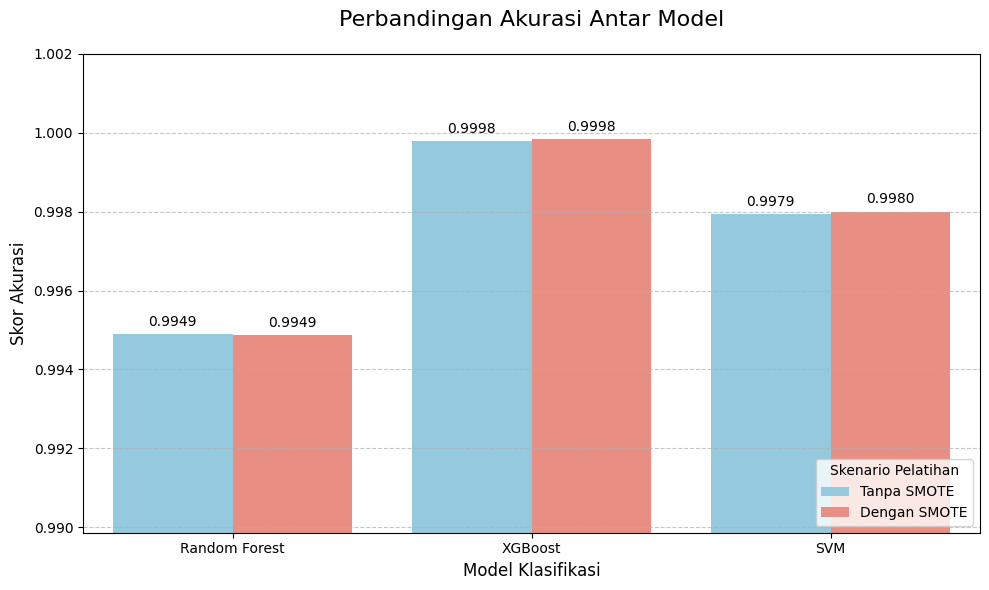

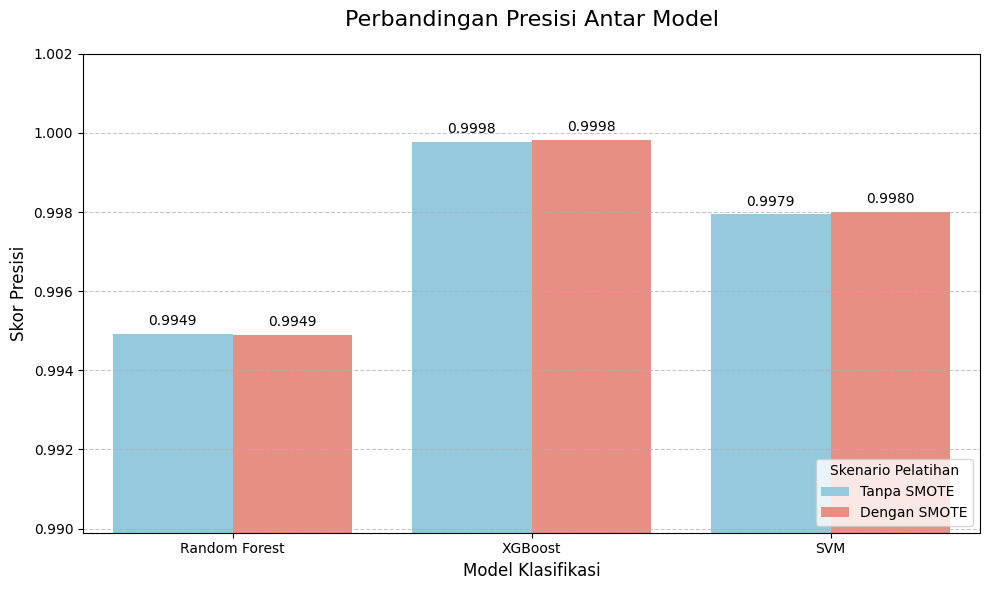

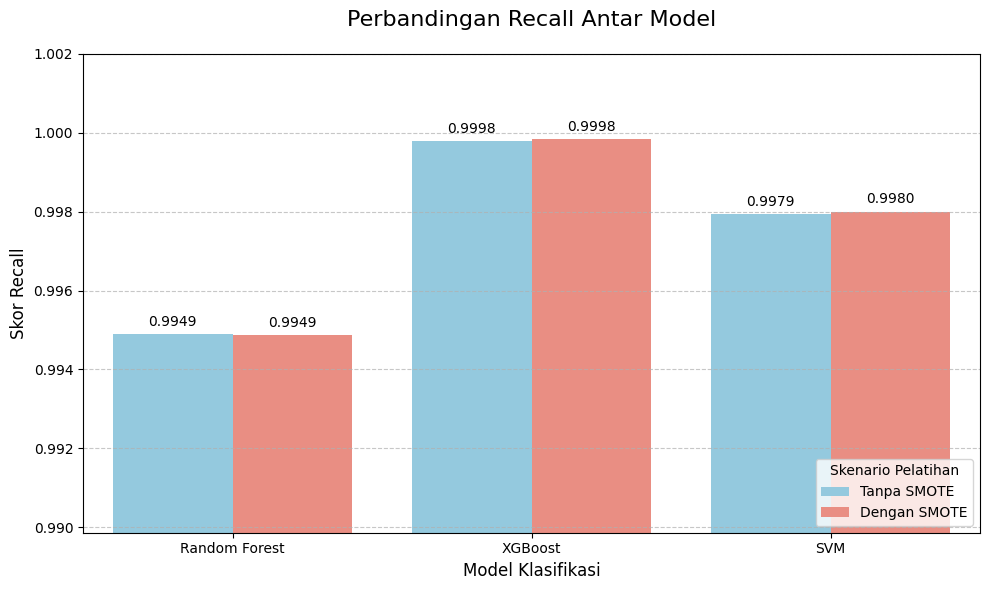

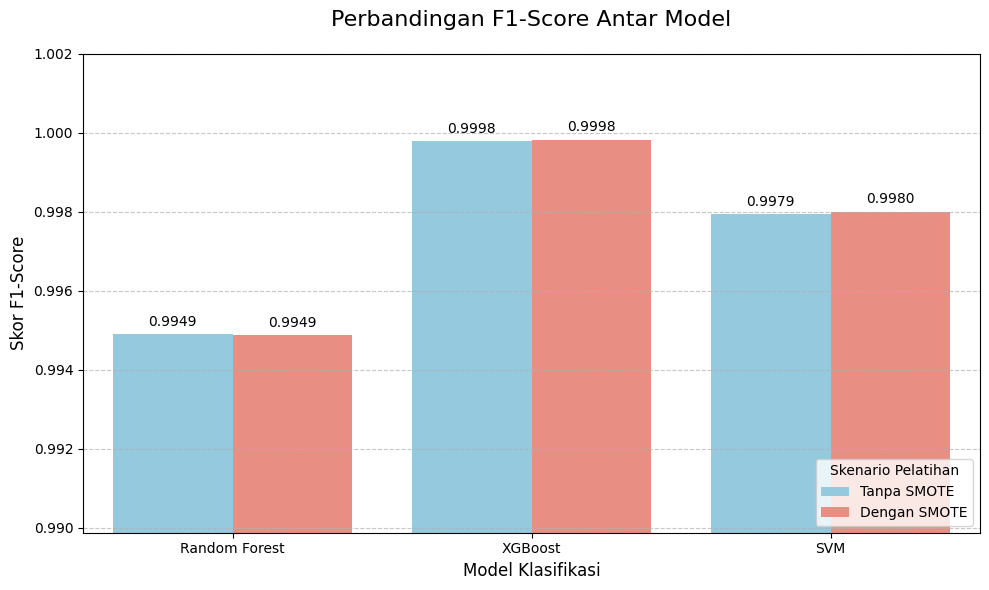



############################################################
                HASIL AKHIR & MODEL TERBAIK
############################################################

Berdasarkan evaluasi keseluruhan pada data uji, model dengan performa terbaik adalah:

  Model      : XGBoost
  Skenario   : Dengan SMOTE
---------------------------------------------
  Detail Performa:
  -> Akurasi    : 0.9998
  -> Presisi    : 0.9998
  -> Recall     : 0.9998
  -> F1-Score   : 0.9998 (Metrik penentu)
---------------------------------------------

Kesimpulan: Penggunaan SMOTE pada data latih terbukti efektif dalam meningkatkan
keseimbangan performa model ini, yang menghasilkan F1-Score tertinggi.


In [6]:
# ===================================================================
# 1. IMPOR PUSTAKA UNTUK VISUALISASI
# ===================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pastikan variabel `results_df` (sebuah DataFrame Pandas)
# sudah ada dari eksekusi CODE UTAMA sebelumnya.

# ===================================================================
# 2. FUNGSI UNTUK MEMBUAT VISUALISASI BAR CHART
# ===================================================================
def plot_comparison_barcharts(results_dataframe):
    """
    Fungsi untuk membuat dan menampilkan bar chart yang membandingkan
    performa setiap model berdasarkan skenario pelatihan.
    
    Args:
        results_dataframe (pd.DataFrame): DataFrame yang berisi hasil evaluasi
                                          dari code_utama.py.
    """
    print("\n\n" + "#"*60)
    print("      MEMBUAT VISUALISASI BAR CHART PERBANDINGAN MODEL")
    print("#"*60)

    # Tentukan metrik yang ingin di-plot
    metrics_to_plot = ['Akurasi', 'Presisi', 'Recall', 'F1-Score']
    
    # Atur palet warna untuk konsistensi
    palette = {"Tanpa SMOTE": "skyblue", "Dengan SMOTE": "salmon"}

    for metric in metrics_to_plot:
        plt.figure(figsize=(10, 6))
        
        # Buat barplot menggunakan Seaborn
        ax = sns.barplot(
            data=results_dataframe, 
            x='Model', 
            y=metric, 
            hue='Skenario',
            palette=palette
        )
        
        # Atur judul dan label
        plt.title(f'Perbandingan {metric} Antar Model', fontsize=16, pad=20)
        plt.xlabel('Model Klasifikasi', fontsize=12)
        plt.ylabel(f'Skor {metric}', fontsize=12)
        
        # Sesuaikan batas sumbu y untuk menyorot perbedaan kecil
        min_score = results_dataframe[metric].min()
        plt.ylim(max(0, min_score - 0.005), 1.002)
        
        # Tambahkan label angka di atas setiap bar
        for p in ax.patches:
            ax.annotate(format(p.get_height(), '.4f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points')

        plt.xticks(rotation=0)
        plt.legend(title='Skenario Pelatihan', loc='lower right')
        plt.tight_layout()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

# ===================================================================
# 3. FUNGSI UNTUK MENAMPILKAN RINGKASAN KESELURUHAN
# ===================================================================
def display_best_model_summary(results_dataframe):
    """
    Fungsi untuk menemukan dan menampilkan model dengan performa terbaik
    berdasarkan F1-Score tertinggi.
    """
    print("\n\n" + "#"*60)
    print("                HASIL AKHIR & MODEL TERBAIK")
    print("#"*60)

    if results_dataframe.empty:
        print("DataFrame hasil evaluasi kosong. Tidak ada yang bisa diringkas.")
        return

    # Cari baris dengan F1-Score tertinggi untuk menentukan model terbaik
    best_model_stats = results_dataframe.loc[results_dataframe['F1-Score'].idxmax()]

    # Ekstrak informasi dari baris terbaik
    model_name = best_model_stats['Model']
    scenario = best_model_stats['Skenario']
    accuracy = best_model_stats['Akurasi']
    precision = best_model_stats['Presisi']
    recall = best_model_stats['Recall']
    f1_score = best_model_stats['F1-Score']

    print("\nBerdasarkan evaluasi keseluruhan pada data uji, model dengan performa terbaik adalah:\n")
    print(f"  Model      : {model_name}")
    print(f"  Skenario   : {scenario}")
    print("-" * 45)
    print("  Detail Performa:")
    print(f"  -> Akurasi    : {accuracy:.4f}")
    print(f"  -> Presisi    : {precision:.4f}")
    print(f"  -> Recall     : {recall:.4f}")
    print(f"  -> F1-Score   : {f1_score:.4f} (Metrik penentu)")
    print("-" * 45)
    
    if "Dengan SMOTE" in scenario:
        print("\nKesimpulan: Penggunaan SMOTE pada data latih terbukti efektif dalam meningkatkan")
        print("keseimbangan performa model ini, yang menghasilkan F1-Score tertinggi.")
    else:
        print("\nKesimpulan: Model ini mencapai performa terbaik bahkan tanpa penyeimbangan")
        print("data latih, menunjukkan ketangguhannya pada data asli.")

# ===================================================================
# 4. GENERATE VISUALISASI DAN TAMPILKAN HASIL AKHIR
# ===================================================================
# Panggil fungsi untuk membuat bar chart dan menampilkan ringkasan
try:
    if 'results_df' in locals() or 'results_df' in globals():
        # 1. Buat visualisasi bar chart
        plot_comparison_barcharts(results_df)
        
        # 2. Tampilkan ringkasan model terbaik
        display_best_model_summary(results_df)
    else:
        print("\n[ERROR] DataFrame 'results_df' tidak ditemukan.")
        print("Pastikan Anda telah menjalankan 'code_utama.py' terlebih dahulu di sesi yang sama.")
except Exception as e:
    print(f"\nTerjadi error saat membuat plot atau ringkasan: {e}")
    print("Pastikan DataFrame 'results_df' memiliki kolom 'Model', 'Skenario', dan metrik yang diperlukan.")



In [1]:
print("\n\nProses pelatihan dan evaluasi selesai. Variabel 'y_test', 'predictions_no_smote', dan 'predictions_with_smote' siap digunakan untuk visualisasi.")



Proses pelatihan dan evaluasi selesai. Variabel 'y_test', 'predictions_no_smote', dan 'predictions_with_smote' siap digunakan untuk visualisasi.
